In [1]:
import os
from pathlib import Path
import mlflow
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from even_flow.utils import set_logger
from even_flow.moons.jobs import(
    MoonsTimeEmbeddingMLPCNFJob
)

logger = set_logger()
mlflow_tracking_path = Path(os.getcwd()).absolute() / 'mlruns'
mlflow.set_tracking_uri(f'file://{mlflow_tracking_path}')
logger.info(f'Set MLflow tracking URI to {mlflow.get_tracking_uri()}')

/home/lucasbanunes/workspaces/even-flow-pearl-jam.mp3/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'default' attribute with value None was provided to the `Field()` function, which has no effect in the context it was used. 'default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(


2025-12-15 17:38:46 | INFO | root | 3433219933 | 16 | Set MLflow tracking URI to file:///home/lucasbanunes/workspaces/even-flow-pearl-jam.mp3/mlruns


In [2]:
experiment_name = 'Moons Exact CNF Corrected Div Scale Addition'
experiment = mlflow.get_experiment_by_name(experiment_name)
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
runs_df = runs_df[runs_df['status'] == 'FINISHED']
runs_df.sort_values(by='metrics.train.loss', inplace=True, ascending=True)
runs_df

/home/lucasbanunes/workspaces/even-flow-pearl-jam.mp3/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.val.eval_duration,metrics.train.z0,metrics.train_int_div_epoch,metrics.val_scaled_int_div,...,params.dataset.random_state,params.model.early_stopping.monitor,params.model.checkpoint.monitor,params.dataset.train_samples,params.slurm.array_job_id,params.model.accelerator,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.source.type
9,76646dccc7f54edf920d276385c57f22,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 18:07:11.079000+00:00,2025-12-15 18:08:27.826000+00:00,0.464238,0.375652,0.632606,0.610517,...,943874,val_loss,val_loss,10000,1090,cpu,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-110,LOCAL
14,478c3c8adbbc4a1f8973399d07511bc2,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 18:04:50.848000+00:00,2025-12-15 18:05:50.797000+00:00,0.404886,0.375652,0.791406,0.807665,...,943874,val_loss,val_loss,10000,1090,cpu,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-105,LOCAL
44,1cc1869b610a450880f9be13de924dd1,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:46:35.118000+00:00,2025-12-15 17:48:55.592000+00:00,1.111502,0.375652,1.081702,1.295611,...,943874,val_loss,val_loss,10000,1090,cpu,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-75,LOCAL
69,55cc9f2888de499da029adfa84ded766,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:26:32.012000+00:00,2025-12-15 17:28:51.876000+00:00,1.018353,0.375652,1.348513,1.331640,...,943874,val_loss,val_loss,10000,1090,cpu,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-50,LOCAL
99,fea7209675fd4c59afefed839bb55a96,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:00:53.761000+00:00,2025-12-15 17:03:33.032000+00:00,1.307558,0.375652,1.372127,1.366397,...,943874,val_loss,val_loss,10000,1090,cpu,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-20,LOCAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,a648c819569140b6ad1cc64dcac0b2f0,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:36:53.204000+00:00,2025-12-15 17:40:41.447000+00:00,1.119501,0.375652,1196.712646,68809.992188,...,943874,val_loss,val_loss,10000,1090,cpu,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-68,LOCAL
75,ca9c1dda6aef44e7bd01712f726aba57,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:19:19.582000+00:00,2025-12-15 17:30:05.089000+00:00,2.363900,0.375652,715.801758,103608.796875,...,943874,val_loss,val_loss,10000,1090,cpu,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-44,LOCAL
81,64406d2e469744af8119a69217a19f3b,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 17:13:43.029000+00:00,2025-12-15 17:23:15.644000+00:00,2.443854,0.375652,2174.398438,123547.843750,...,943874,val_loss,val_loss,10000,1090,cpu,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-38,LOCAL
15,0e09157f80e14e7cbb6162f5c68f3727,181512178531093206,FINISHED,file:///home/lucasbanunes/workspaces/even-flow...,2025-12-15 18:04:32.411000+00:00,2025-12-15 18:08:07.588000+00:00,1.000715,0.375652,975.028992,143010.562500,...,943874,val_loss,val_loss,10000,1090,cpu,lucas.nunes,/home/lucasbanunes/workspaces/even-flow-pearl-...,exact-cnf-moons-104,LOCAL


In [3]:
for i, col in enumerate(runs_df.columns):
    if not (col.startswith('metrics.train') and col.endswith('epoch')):
        continue
    print(f'{i} - {col}')

8 - metrics.train_int_div_epoch
36 - metrics.train_scaled_int_div_epoch
41 - metrics.train_z0_epoch
44 - metrics.train_logp_z0_epoch
47 - metrics.train_loss_epoch
57 - metrics.train_scaled_logp_z0_epoch
63 - metrics.train_zf_epoch
70 - metrics.train_logp_zf_epoch


/tmp/ipykernel_1448678/819874771.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1448678/819874771.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1448678/819874771.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1448678/819874771.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')


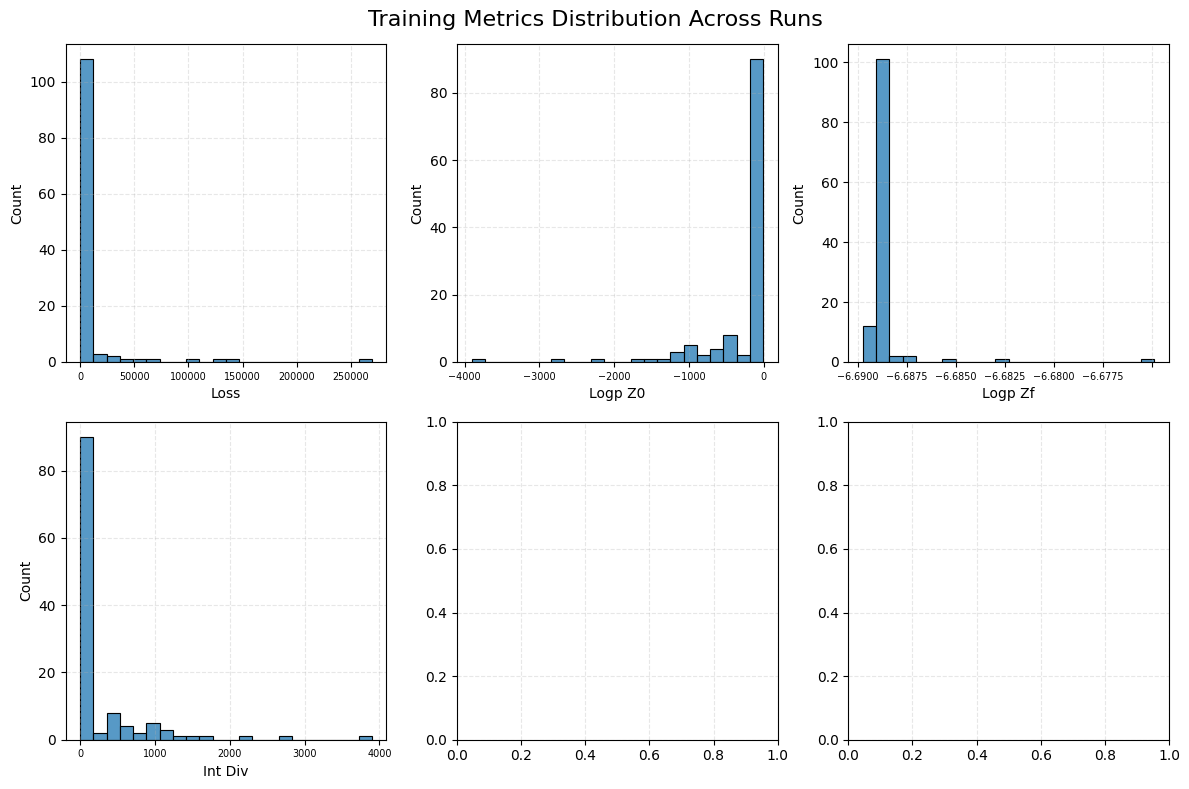

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
x_values = [
    'metrics.train.loss',
    'metrics.train.logp_z0',
    'metrics.train.logp_zf',
    'metrics.train.int_div',
]
for ax in axes.flatten():
    ax.grid(alpha=.3, linestyle='--')
for i in range(len(x_values)):
    x = x_values[i]
    metric_name = x.split('.')[-1]
    ax = axes.flatten()[i] if len(x_values) > 1 else axes
    # ax.set_xscale('log')
    ax.grid(alpha=.3, linestyle='--')
    ax.set(
        xlabel=' '.join(metric_name.split('_')).title(),
    )
    sns.histplot(
        data=runs_df,
        x=x,
        ax=ax,
    )
    ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
fig.suptitle('Training Metrics Distribution Across Runs', fontsize=16)
fig.tight_layout()

/tmp/ipykernel_1448678/1083414914.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1448678/1083414914.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1448678/1083414914.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
/tmp/ipykernel_1448678/1083414914.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')


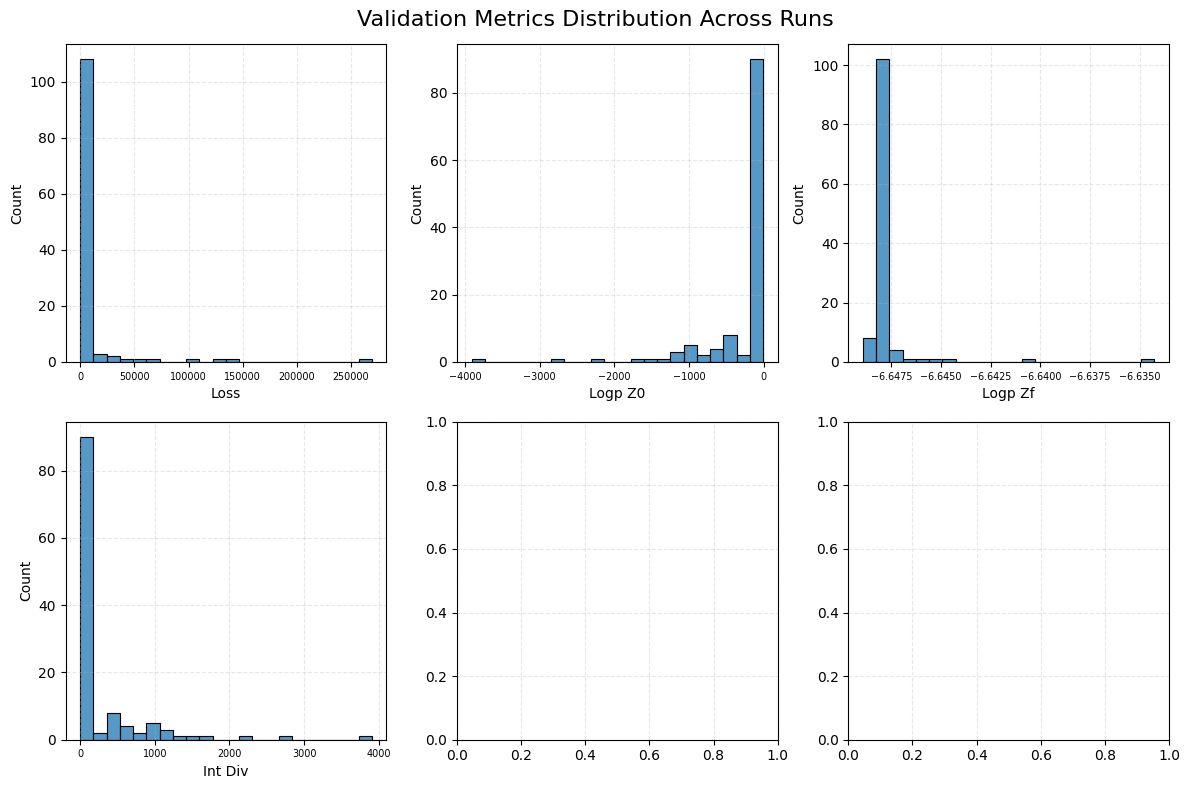

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
x_values = [
    'metrics.val.loss',
    'metrics.val.logp_z0',
    'metrics.val.logp_zf',
    'metrics.val.int_div',
]
for ax in axes.flatten():
    ax.grid(alpha=.3, linestyle='--')
for i in range(len(x_values)):
    x = x_values[i]
    metric_name = x.split('.')[-1]
    ax = axes.flatten()[i] if len(x_values) > 1 else axes
    # ax.set_xscale('log')
    ax.grid(alpha=.3, linestyle='--')
    ax.set(
        xlabel=' '.join(metric_name.split('_')).title(),
    )
    sns.histplot(
        data=runs_df,
        x=x,
        ax=ax,
    )
    ax.set_xticklabels(labels=ax.get_xticklabels(), fontsize='x-small')
fig.suptitle('Validation Metrics Distribution Across Runs', fontsize=16)
fig.tight_layout()

In [6]:
min_val_loss_run = runs_df.loc[runs_df['metrics.val.loss'].idxmin()]
min_val_loss_job = MoonsTimeEmbeddingMLPCNFJob.from_mlflow_run_id(min_val_loss_run['run_id'])
min_val_loss_job

/home/lucasbanunes/workspaces/even-flow-pearl-jam.mp3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MoonsTimeEmbeddingMLPCNFJob(id_='76646dccc7f54edf920d276385c57f22', name='exact-cnf-moons-110', prefix='', slurm=SlurmEnvironment(id_='76646dccc7f54edf920d276385c57f22', name='exact-cnf-moons-110', prefix='slurm', job_id='1202', job_name='run_moons', array_job_id='1090', array_task_id='110'), dataset=MoonsDataset(id_='76646dccc7f54edf920d276385c57f22', name='exact-cnf-moons-110', prefix='dataset', train_samples=10000, val_samples=1000, test_samples=1000, noise=0.05, batch_size=32, random_state=943874), model=TimeEmbeddingMLPCNFModel(id_='76646dccc7f54edf920d276385c57f22', name='exact-cnf-moons-110', prefix='model', accelerator='cpu', profiler='simple', max_epochs=50, num_sanity_val_steps=5, enable_progress_bar=False, enable_model_summary=True, max_time={'hours': 11}, checkpoint=ModelCheckpointConfig(id_='76646dccc7f54edf920d276385c57f22', name='exact-cnf-moons-110', prefix='model.checkpoint', dirpath=None, monitor='val_loss', mode='min', save_top_k=3, filename='checkpoint-{epoch:02d}-{

In [7]:
y_values = [
    'epoch',
    'train_loss_epoch',
    'train_logp_z0_epoch',
    'train_logp_zf_epoch',
    'train_int_div_epoch',
]
label_map = {
    y: ' '.join(y.split('_')[1:-1]).title() for y in y_values
}
label_map['epoch'] = 'Epoch'
min_val_loss_metric_history = min_val_loss_job.get_metric_history(y_values).dropna()
min_val_loss_metric_history.rename(label_map, axis=1, inplace=True)
min_val_loss_metric_history

,Epoch,Loss,Logp Z0,Logp Zf,Int Div,step
312,0.0,6.575742,-6.575742,-6.687624,0.111879,312
625,1.0,6.198151,-6.198151,-6.691066,0.492915,625
938,2.0,6.104935,-6.104935,-6.689786,0.584853,938
1251,3.0,6.056841,-6.056841,-6.689451,0.632606,1251


In [8]:
y_values = [
    'epoch',
    'train_loss_epoch',
    'train_logp_z0_epoch',
    'train_logp_zf_epoch',
    'train_int_div_epoch',
]
label_map = {
    y: ' '.join(y.split('_')[1:-1]).title() for y in y_values
}
label_map['epoch'] = 'Epoch'
data = min_val_loss_job.get_metric_history(y_values).dropna()
data.rename(label_map, axis=1, inplace=True)

fig = px.line(
    data,
    x='Epoch',
    y=list(label_map.values()),
    title='Training Metrics Over Epochs for Best Validation Loss Run',
    markers=True
)
fig.update_layout(legend=dict(title='Variable'))
fig.show()

In [9]:
y_values = [
    'epoch',
    'val_loss',
    'val_logp_z0',
    'val_logp_zf',
    'val_int_div',
]
label_map = {
    y: ' '.join(y.split('_')[1:]).title() for y in y_values
}
label_map['epoch'] = 'Epoch'
data = min_val_loss_job.get_metric_history(y_values).dropna()
data.rename(label_map, axis=1, inplace=True)

fig = px.line(
    data,
    x='Epoch',
    y=list(label_map.values()),
    title='Validation Metrics Over Epochs for Best Validation Loss Run',
    markers=True
)
fig.update_layout(legend=dict(title='Variable'))
fig.show()